# Notebook 2 — Limpieza, Feature Engineering y EDA

**Objetivo**: partir del histórico crudo (Notebook 1) y llegar a un tablón de features listo
para modelar, validando por el camino los supuestos estadísticos en los que se apoya ese
modelado. Dos partes:

- **2.1 a 2.7**: limpieza, historial cara a cara, Elo sin fuga temporal, ventanas móviles de
  forma/racha/descanso, y ensamblado del tablón final -- `data/processed/partidos_features.csv`.
- **3.1 a 3.4**: con ese mismo tablón ya en memoria (sin releerlo del disco), se comprueba que
  los goles siguen aproximadamente una Poisson, que el fútbol antes de 1990 no es comparable al
  actual, que no hay colinealidad problemática entre features, y que el Elo por sí solo ya separa
  razonablemente ganadores de perdedores -- la cota mínima que cualquier modelo debe superar.

Entrada: `data/raw/results.csv`, `data/raw/elo_historico.csv` (Notebook 1).
Salida: `data/processed/partidos_features.csv` + las conclusiones que consume el Notebook 3.

In [1]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

DIR_RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_RAW = DIR_RAIZ / "data" / "raw"
DIR_PROCESSED = DIR_RAIZ / "data" / "processed"
DIR_PROCESSED.mkdir(parents=True, exist_ok=True)

VENTANAS_ROLLING = (5, 10)   # partidos previos sobre los que promediar forma
DIAS_TENDENCIA_ELO = 180     # ~6 meses, para el feature de tendencia de Elo

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 160)

df_partidos = pd.read_csv(DIR_RAW / "results.csv", parse_dates=["date"])
df_elo = pd.read_csv(DIR_RAW / "elo_historico.csv", parse_dates=["fecha"])

print(f"Partidos: {len(df_partidos):,}  |  Filas de Elo: {len(df_elo):,}")

Partidos: 49,505  |  Filas de Elo: 34,767


## 2.1 Limpieza básica

Normalización de nombres de columna, tipado y una regla de negocio explícita: un
partido sin marcador (programado pero aún no jugado — el caso de las eliminatorias
del Mundial 2026 que siguen en juego) se conserva pero se marca aparte, porque **no
debe entrar como fila de entrenamiento**, aunque sí puede ser el objeto de una
predicción más adelante.

In [2]:
def limpiar_partidos(df: pd.DataFrame) -> pd.DataFrame:
    """Tipa y normaliza el histórico crudo; no elimina partidos sin marcador
    (los necesita el Notebook 4 para saber qué predecir), solo los señala.
    """
    df = df.rename(columns={
        "date": "fecha", "home_team": "equipo_local", "away_team": "equipo_visitante",
        "home_score": "goles_local", "away_score": "goles_visitante",
        "tournament": "torneo", "neutral": "es_neutral",
    }).copy()

    df["fecha"] = pd.to_datetime(df["fecha"])
    df["jugado"] = df["goles_local"].notna() & df["goles_visitante"].notna()
    df["es_neutral"] = df["es_neutral"].astype(bool)

    # Duplicados por (día, equipos): distintas fuentes pueden registrar el
    # mismo partido con una hora ligeramente distinta — comparar solo el día
    # evita contarlo dos veces en las ventanas móviles de más abajo.
    df["_dia"] = df["fecha"].dt.normalize()
    antes = len(df)
    df = df.drop_duplicates(subset=["_dia", "equipo_local", "equipo_visitante"]).drop(columns="_dia")
    if antes - len(df):
        print(f"Eliminados {antes - len(df)} partidos duplicados (mismo día y equipos)")

    return df.sort_values("fecha").reset_index(drop=True)


df_partidos = limpiar_partidos(df_partidos)
print(f"Partidos jugados: {df_partidos['jugado'].sum():,} / {len(df_partidos):,} totales")
df_partidos.tail()

Eliminados 2 partidos duplicados (mismo día y equipos)
Partidos jugados: 49,499 / 49,503 totales


,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,torneo,city,country,es_neutral,jugado
49498,2026-07-07,Argentina,Egypt,3.0,2.0,FIFA World Cup,Atlanta,United States,True,True
49499,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True,False
49500,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True,False
49501,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,False
49502,2026-07-11,Argentina,Switzerland,NaN,NaN,FIFA World Cup,Kansas City,United States,True,False


## 2.2 Historial cara a cara (H2H)

Elo y forma reciente son resúmenes agregados: no distinguen si España lleva 15 años sin
ganarle a Marruecos en concreto. El balance de los enfrentamientos directos entre estas
DOS selecciones (sea cual fuera el campo en esos partidos previos) es una señal clásica
de predicción de fútbol que hasta ahora no se estaba usando, y no hace falta ningún dato
nuevo — ya está en `results.csv`.

Sin ventana temporal (a diferencia de `prom_gf`/`racha_puntos`): la mayoría de parejas
de selecciones se han enfrentado muy pocas veces en toda la historia, así que limitar a
"los últimos N cara a cara" dejaría a la mayoría de partidos sin ninguna señal. Se usa
el balance de TODOS los enfrentamientos anteriores.

In [3]:
def calcular_h2h(df_partidos: pd.DataFrame) -> pd.DataFrame:
    """Para cada partido: balance de TODOS los enfrentamientos previos entre
    esas dos selecciones concretas, siempre desde la perspectiva de quien es
    local EN EL PARTIDO ACTUAL (si en un cara a cara anterior el equipo local
    de ahora jugó como visitante, se voltea el signo). Un partido solo entra
    al historial DESPUÉS de calcular el feature de su propia fila, y solo si
    ya se jugó -- un partido programado no puede informar el h2h de otro.
    """
    df = df_partidos.sort_values("fecha").reset_index(drop=True)
    historial: dict[frozenset, list[dict]] = defaultdict(list)

    puntos_prom, dif_goles_prom, n_partidos = [], [], []
    for fila in df.itertuples(index=False):
        clave = frozenset({fila.equipo_local, fila.equipo_visitante})
        previos = historial[clave]

        if previos:
            puntos, difs = [], []
            for p in previos:
                if p["equipo_local"] == fila.equipo_local:
                    puntos.append(p["puntos_local"])
                    difs.append(p["goles_local"] - p["goles_visitante"])
                else:
                    puntos.append(p["puntos_visitante"])
                    difs.append(p["goles_visitante"] - p["goles_local"])
            puntos_prom.append(np.mean(puntos))
            dif_goles_prom.append(np.mean(difs))
            n_partidos.append(len(previos))
        else:
            puntos_prom.append(np.nan)
            dif_goles_prom.append(np.nan)
            n_partidos.append(0)

        if fila.jugado:
            puntos_local = 3 if fila.goles_local > fila.goles_visitante else (1 if fila.goles_local == fila.goles_visitante else 0)
            puntos_visitante = 3 if fila.goles_visitante > fila.goles_local else (1 if fila.goles_local == fila.goles_visitante else 0)
            historial[clave].append({
                "equipo_local": fila.equipo_local, "equipo_visitante": fila.equipo_visitante,
                "goles_local": fila.goles_local, "goles_visitante": fila.goles_visitante,
                "puntos_local": puntos_local, "puntos_visitante": puntos_visitante,
            })

    df["h2h_puntos_prom"] = puntos_prom
    df["h2h_dif_goles_prom"] = dif_goles_prom
    df["h2h_n_partidos"] = n_partidos

    # Sin enfrentamientos previos entre estas dos selecciones concretas:
    # neutro, igual que el resto de features de forma sin historial -- ni el
    # local ni el visitante llevan ventaja psicológica/táctica conocida el
    # uno sobre el otro.
    df["h2h_puntos_prom"] = df["h2h_puntos_prom"].fillna(1.0)
    df["h2h_dif_goles_prom"] = df["h2h_dif_goles_prom"].fillna(0.0)

    return df


df_partidos = calcular_h2h(df_partidos)
print(f"Parejas de selecciones con al menos un cara a cara previo: "
      f"{(df_partidos['h2h_n_partidos'] > 0).sum():,} / {len(df_partidos):,} partidos")
df_partidos[["fecha", "equipo_local", "equipo_visitante", "h2h_puntos_prom", "h2h_dif_goles_prom", "h2h_n_partidos"]].tail()

Parejas de selecciones con al menos un cara a cara previo: 41,956 / 49,503 partidos


,fecha,equipo_local,equipo_visitante,h2h_puntos_prom,h2h_dif_goles_prom,h2h_n_partidos
49498,2026-07-07,Argentina,Egypt,3.000000,4.000000,2
49499,2026-07-09,France,Morocco,2.333333,1.333333,6
49500,2026-07-10,Spain,Belgium,1.772727,1.000000,22
49501,2026-07-11,Norway,England,0.750000,-1.750000,12
49502,2026-07-11,Argentina,Switzerland,2.428571,1.714286,7


## 2.2b Estadísticas avanzadas de SofaScore (posesión, tiros, corners, faltas)

`data/raw/sofascore_partidos.csv` / `sofascore_estadisticas.csv` (scraper dedicado,
`scripts/scrape_sofascore.py`) traen estadísticas de partido que `results.csv` nunca ha
tenido: posesión, tiros a puerta, corners y faltas. Solo cubren las 48 selecciones del
Mundial 2026 (y, de rebote, a cualquier rival suyo en esos partidos concretos) — es una
señal escasa pero real, distinta de todo lo demás en este notebook porque no viene del
mismo par de fuentes que el resto del tablón.

Cruzar ambas fuentes no es trivial: SofaScore nombra algunas selecciones distinto que
`results.csv` (`Türkiye` vs `Turkey`, `Côte d'Ivoire` vs `Ivory Coast`...) y su fecha de
partido a veces difiere en 1-2 días del mirror (zona horaria del kickoff). Comprobado en la
práctica: un cruce exacto (fecha + equipos) solo casa el 68% de los 9361 partidos de
SofaScore; con el alias de nombres sube a 81.5%, y añadiendo una segunda pasada tolerante
(mismo par de selecciones, fecha más cercana dentro de ±2 días) sube a 94.5% — el 5.5%
restante no son variantes de nombre sino partidos que no son internacionales A completos
(amistosos contra clubes, selecciones sub-23, entidades históricas como la URSS que
`results.csv` no registra igual) y correctamente no deben casar con nada.

In [4]:
RUTA_SOFASCORE_PARTIDOS = DIR_RAW / "sofascore_partidos.csv"
RUTA_SOFASCORE_ESTADISTICAS = DIR_RAW / "sofascore_estadisticas.csv"

# Solo estas 4 columnas de las ~50 que trae el scraper: comprobado que son
# las mejor pobladas (90-98% de los partidos con estadísticas) y las más
# clásicas/interpretables. `expectedGoals` se descartó pese a ser señal muy
# fuerte -- solo el 17.7% de los partidos con estadísticas la traen (SofaScore
# no calculaba xG en la mayoría de competiciones antes de hace pocos años),
# demasiado escasa para un feature nuevo cuya utilidad aún no está probada.
COLUMNAS_STATS_SOFASCORE = ["ballPossession", "totalShotsOnGoal", "cornerKicks", "fouls"]
NOMBRES_STATS_SOFASCORE = {
    "ballPossession": "posesion", "totalShotsOnGoal": "tiros", "cornerKicks": "corners", "fouls": "faltas",
}

# Selecciones que SofaScore nombra distinto que results.csv -- encontradas
# comparando el conjunto de nombres de ambas fuentes, no adivinadas. El resto
# de nombres sin alias que no casan (Yugoslavia, URSS, Alemania Occidental,
# equipos de club, categorías sub-23...) no son variantes de nombre reales,
# son partidos que no deben casar (ver celda anterior).
ALIAS_SOFASCORE_RESULTADOS = {
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Cabo Verde": "Cape Verde",
    "Czechia": "Czech Republic",
    "Côte d'Ivoire": "Ivory Coast",
    "Türkiye": "Turkey",
    "USA": "United States",
    "Ireland": "Republic of Ireland",
    "Chinese Taipei": "Taiwan",
    "Congo Republic": "Congo",
}


def emparejar_sofascore_con_resultados(df_partidos: pd.DataFrame, ruta_partidos_sofa: Path,
                                        ruta_estadisticas_sofa: Path) -> pd.DataFrame:
    """Añade a `df_partidos` (ya limpio, una fila por partido) las columnas
    `{posesion,tiros,corners,faltas}_{local,visitante}` cuando existe un
    partido de SofaScore emparejable -- NaN en el resto (la inmensa mayoría:
    SofaScore solo cubre las 48 selecciones del Mundial 2026).

    Dos pasadas de cruce, igual que se comprobó necesario en el análisis
    previo: exacta (fecha + equipos, con alias de nombre aplicado) y, para lo
    que quede sin casar, tolerante (mismo par de selecciones sin importar
    local/visitante, fecha más cercana dentro de ±2 días -- cubre el desfase
    de zona horaria del kickoff entre fuentes). Si SofaScore listó el partido
    con local/visitante invertido respecto a `results.csv`, se detecta
    (`flip`) y se voltean las columnas de estadísticas para que sigan
    describiendo al mismo equipo que el resto del tablón.
    """
    if not ruta_partidos_sofa.exists() or not ruta_estadisticas_sofa.exists():
        print("[aviso] No hay datos de SofaScore todavía -- se omite esta sección "
              "(ejecuta scripts/scrape_sofascore.py antes de correr este notebook para incluirla).")
        cols_vacias = [f"{NOMBRES_STATS_SOFASCORE[c]}_{lado}" for c in COLUMNAS_STATS_SOFASCORE for lado in ("local", "visitante")]
        return df_partidos.assign(**{c: np.nan for c in cols_vacias})

    partidos_sofa = pd.read_csv(ruta_partidos_sofa, parse_dates=["fecha"])
    estadisticas_sofa = pd.read_csv(ruta_estadisticas_sofa)

    p = partidos_sofa.copy()
    p["equipo_local"] = p["equipo_local"].replace(ALIAS_SOFASCORE_RESULTADOS)
    p["equipo_visitante"] = p["equipo_visitante"].replace(ALIAS_SOFASCORE_RESULTADOS)

    resultados = df_partidos[["fecha", "equipo_local", "equipo_visitante"]].reset_index().rename(
        columns={"index": "idx_resultado"})

    exacto = p.merge(resultados, on=["fecha", "equipo_local", "equipo_visitante"], how="inner")
    exacto = exacto.assign(flip=False)

    pendientes = p[~p["event_id"].isin(exacto["event_id"])]
    resultados_por_par: dict[frozenset, list] = {}
    for fila in resultados.itertuples():
        resultados_por_par.setdefault(frozenset({fila.equipo_local, fila.equipo_visitante}), []).append(fila)

    filas_tolerantes = []
    for fila in pendientes.itertuples():
        candidatos = resultados_por_par.get(frozenset({fila.equipo_local, fila.equipo_visitante}), [])
        if not candidatos:
            continue
        mejor = min(candidatos, key=lambda r: abs((r.fecha - fila.fecha).days))
        if abs((mejor.fecha - fila.fecha).days) > 2:
            continue
        filas_tolerantes.append({
            "event_id": fila.event_id, "idx_resultado": mejor.idx_resultado,
            "flip": mejor.equipo_local != fila.equipo_local,
        })

    emparejamiento = pd.concat([
        exacto[["event_id", "idx_resultado", "flip"]], pd.DataFrame(filas_tolerantes),
    ], ignore_index=True)

    # Dos partidos de SofaScore (event_id distintos) pueden apuntar al MISMO
    # partido real de results.csv -- comprobado en la práctica (7 casos): el
    # mismo encuentro listado dos veces por SofaScore con ids diferentes. Se
    # prefiere el que sí trae estadísticas; si ninguno o los dos las traen,
    # el de event_id más bajo, por determinismo.
    emparejamiento["tiene_stats"] = emparejamiento["event_id"].isin(estadisticas_sofa["event_id"])
    emparejamiento = emparejamiento.sort_values(["idx_resultado", "tiene_stats", "event_id"], ascending=[True, False, True])
    emparejamiento = emparejamiento.drop_duplicates(subset="idx_resultado", keep="first")
    assert emparejamiento["idx_resultado"].duplicated().sum() == 0, "idx_resultado duplicado tras deduplicar"

    cols_local = [f"{c}_local" for c in COLUMNAS_STATS_SOFASCORE]
    cols_visitante = [f"{c}_visitante" for c in COLUMNAS_STATS_SOFASCORE]
    stats_join = emparejamiento.merge(estadisticas_sofa[["event_id"] + cols_local + cols_visitante],
                                       on="event_id", how="left")

    for c in COLUMNAS_STATS_SOFASCORE:
        l, v = f"{c}_local", f"{c}_visitante"
        valor_local = np.where(stats_join["flip"], stats_join[v], stats_join[l])
        valor_visitante = np.where(stats_join["flip"], stats_join[l], stats_join[v])
        stats_join[l], stats_join[v] = valor_local, valor_visitante

    renombre = ({f"{c}_local": f"{NOMBRES_STATS_SOFASCORE[c]}_local" for c in COLUMNAS_STATS_SOFASCORE} |
                {f"{c}_visitante": f"{NOMBRES_STATS_SOFASCORE[c]}_visitante" for c in COLUMNAS_STATS_SOFASCORE})
    stats_por_partido = stats_join[["idx_resultado"] + cols_local + cols_visitante].rename(columns=renombre)

    df_partidos = df_partidos.reset_index().rename(columns={"index": "idx_resultado"}).merge(
        stats_por_partido, on="idx_resultado", how="left").drop(columns="idx_resultado")

    n_con_stats = df_partidos.filter(regex="posesion_local|tiros_local|corners_local|faltas_local").notna().any(axis=1).sum()
    print(f"SofaScore emparejado: {len(emparejamiento):,}/{len(p):,} partidos ({len(emparejamiento)/len(p)*100:.1f}%); "
          f"{n_con_stats:,} partidos de results.csv terminan con alguna estadística real.")
    return df_partidos


df_partidos = emparejar_sofascore_con_resultados(df_partidos, RUTA_SOFASCORE_PARTIDOS, RUTA_SOFASCORE_ESTADISTICAS)
df_partidos.filter(regex="fecha|equipo|posesion|tiros_local").tail()

SofaScore emparejado: 8,842/9,361 partidos (94.5%); 4,508 partidos de results.csv terminan con alguna estadística real.


,fecha,equipo_local,equipo_visitante,posesion_local,tiros_local,posesion_visitante
49498,2026-07-07,Argentina,Egypt,NaN,NaN,NaN
49499,2026-07-09,France,Morocco,NaN,NaN,NaN
49500,2026-07-10,Spain,Belgium,NaN,NaN,NaN
49501,2026-07-11,Norway,England,NaN,NaN,NaN
49502,2026-07-11,Argentina,Switzerland,NaN,NaN,NaN


## 2.3 Formato largo (una fila = un equipo en un partido)

Las ventanas móviles ("¿cómo le fueron a este equipo sus últimos N partidos?") son
triviales en formato largo y un infierno en formato ancho (local/visitante como
columnas separadas). Se paga la duplicación de memoria aquí a cambio de no mantener
dos ramas de código idénticas para cada feature.

In [5]:
COLUMNAS_STATS_LARGO = [NOMBRES_STATS_SOFASCORE[c] for c in COLUMNAS_STATS_SOFASCORE]


def a_formato_largo(df: pd.DataFrame) -> pd.DataFrame:
    """Duplica cada partido en dos filas, una por equipo, con 'gf'/'gc'
    (goles a favor / en contra) desde la perspectiva de ESE equipo. También
    arrastra las estadísticas de SofaScore (2.2b) con el mismo criterio
    local/visitante -> perspectiva del equipo, para que sus ventanas móviles
    (2.5) se calculen igual que prom_gf/prom_gc.
    """
    base = ["fecha", "torneo", "jugado"]
    cols_stats_local = [f"{s}_local" for s in COLUMNAS_STATS_LARGO]
    cols_stats_visitante = [f"{s}_visitante" for s in COLUMNAS_STATS_LARGO]

    local = df[base + ["equipo_local", "goles_local", "goles_visitante"] + cols_stats_local].rename(
        columns={"equipo_local": "equipo", "goles_local": "gf", "goles_visitante": "gc",
                 **{f"{s}_local": s for s in COLUMNAS_STATS_LARGO}}
    )
    local["es_local"] = True
    visitante = df[base + ["equipo_visitante", "goles_visitante", "goles_local"] + cols_stats_visitante].rename(
        columns={"equipo_visitante": "equipo", "goles_visitante": "gf", "goles_local": "gc",
                 **{f"{s}_visitante": s for s in COLUMNAS_STATS_LARGO}}
    )
    visitante["es_local"] = False

    largo = pd.concat([local, visitante], ignore_index=True)
    largo["id_partido"] = pd.concat([df.index.to_series(), df.index.to_series()], ignore_index=True)
    largo = largo.sort_values(["equipo", "fecha"]).reset_index(drop=True)

    # Puntos solo tienen sentido para partidos ya jugados.
    largo["puntos"] = np.select(
        [largo["jugado"] & (largo.gf > largo.gc), largo["jugado"] & (largo.gf == largo.gc)],
        [3, 1], default=np.where(largo["jugado"], 0, np.nan),
    )
    return largo


df_largo = a_formato_largo(df_partidos)
df_largo.head()

,fecha,torneo,jugado,equipo,gf,gc,posesion,tiros,corners,faltas,es_local,id_partido,puntos
0,2012-09-25,Friendly,True,Abkhazia,1.0,1.0,NaN,NaN,NaN,NaN,True,36259,1.0
1,2012-10-21,Friendly,True,Abkhazia,0.0,3.0,NaN,NaN,NaN,NaN,False,36403,0.0
2,2013-09-23,Friendly,True,Abkhazia,3.0,0.0,NaN,NaN,NaN,NaN,True,37316,3.0
3,2014-06-01,CONIFA World Football Cup,True,Abkhazia,1.0,1.0,NaN,NaN,NaN,NaN,True,37776,1.0
4,2014-06-02,CONIFA World Football Cup,True,Abkhazia,2.0,1.0,NaN,NaN,NaN,NaN,False,37796,3.0


## 2.4 Elo exacto por fecha (sin fuga)

Cada fila del histórico de Elo trae la puntuación **posterior** al partido de esa
selección. Para asignar a un partido el Elo que un equipo tenía **antes** de jugarlo
—incluido el caso en que la fecha coincide exactamente con una fila de su propio
historial de Elo, que es precisamente el caso de los partidos que se quieren predecir—
se calcula primero `elo_antes = elo.shift(1)` dentro de cada selección, y **sobre esa
serie ya desplazada** se hace el cruce por fecha (`merge_asof` hacia atrás). Sin el
`shift(1)` previo, un partido tomaría su propio Elo posterior como si fuera el de
entrada: la fuga de información más sutil (y más grave) de todo el pipeline.

In [6]:
def calcular_elo_antes_partido(df_elo: pd.DataFrame) -> pd.DataFrame:
    """Añade 'elo_antes': el Elo de la selección ENTRANDO a cada partido suyo."""
    df_elo = df_elo.sort_values(["equipo", "fecha"]).copy()
    df_elo["elo_antes"] = df_elo.groupby("equipo")["elo"].shift(1)
    # Antes del primer partido registrado de una selección: 1500 es el punto
    # de partida estándar de cualquier sistema Elo (ausencia total de
    # información previa), no un valor inventado ad hoc.
    df_elo["elo_antes"] = df_elo["elo_antes"].fillna(1500.0)
    return df_elo[["equipo", "fecha", "elo_antes"]]


def asignar_elo_por_fecha(df_largo: pd.DataFrame, df_elo_antes: pd.DataFrame,
                           dias_atras: int = 0, nombre_columna: str = "elo") -> pd.Series:
    """Cruza cada fila de `df_largo` con el Elo de ESE equipo vigente en su fecha
    (o `dias_atras` antes, para el feature de tendencia). `merge_asof` exige
    ambos lados ordenados por la columna de cruce.
    """
    izquierda = df_largo[["equipo", "fecha"]].copy()
    izquierda["fecha_consulta"] = izquierda["fecha"] - pd.Timedelta(days=dias_atras)
    izquierda = izquierda.reset_index().sort_values("fecha_consulta")

    cruce = pd.merge_asof(
        izquierda, df_elo_antes.sort_values("fecha"),
        left_on="fecha_consulta", right_on="fecha", by="equipo", direction="backward",
    ).set_index("index").sort_index()

    return cruce["elo_antes"].rename(nombre_columna)


df_elo_antes = calcular_elo_antes_partido(df_elo)

df_largo["elo_actual"] = asignar_elo_por_fecha(df_largo, df_elo_antes)
df_largo["elo_hace_180d"] = asignar_elo_por_fecha(df_largo, df_elo_antes, dias_atras=DIAS_TENDENCIA_ELO)

# Sin Elo real de hace 180 días (selección con menos de ~6 meses de historial
# en el dataset, o fuera del histórico de Elo por completo): "sin tendencia"
# es la respuesta honesta, no restar contra el 1500 de relleno de más abajo
# -- eso inventaría una subida/bajada que no es real, mezclando una selección
# con Elo real actual y un punto de comparación neutro de hace 180 días.
# Coherente con el resto de features de esta sección: sin historial -> valor
# neutro, nunca un cálculo que aparente señal real donde no la hay.
sin_tendencia_fiable = df_largo["elo_hace_180d"].isna()

# Selecciones fuera del histórico de Elo (no forman parte del Mundial 2026):
# 1500 neutro, igual que un equipo sin historial — no invalida el resto de
# features de ese partido, solo dice "no tenemos información de Elo aquí".
df_largo[["elo_actual", "elo_hace_180d"]] = df_largo[["elo_actual", "elo_hace_180d"]].fillna(1500.0)
df_largo["tendencia_elo"] = df_largo["elo_actual"] - df_largo["elo_hace_180d"]
df_largo.loc[sin_tendencia_fiable, "tendencia_elo"] = 0.0

df_largo[["equipo", "fecha", "elo_actual", "elo_hace_180d", "tendencia_elo"]].tail()

,equipo,fecha,elo_actual,elo_hace_180d,tendencia_elo
99001,Åland Islands,2017-06-29,1500.0,1500.0,0.0
99002,Åland Islands,2023-07-09,1500.0,1500.0,0.0
99003,Åland Islands,2023-07-10,1500.0,1500.0,0.0
99004,Åland Islands,2023-07-11,1500.0,1500.0,0.0
99005,Åland Islands,2023-07-13,1500.0,1500.0,0.0


## 2.5 Ventanas móviles (forma, racha, descanso)

Para cada ventana de `VENTANAS_ROLLING` (5 y 10 partidos): promedio de goles a favor
y en contra, y racha de puntos. Siempre `shift(1)` antes del `rolling`: la fila del
partido en curso nunca puede ver su propio resultado.

In [7]:
def calcular_features_forma(df_largo: pd.DataFrame, ventanas: tuple[int, ...]) -> pd.DataFrame:
    """Añade, por cada ventana N: prom_gf_N, prom_gc_N (forma ofensiva/defensiva)
    y racha_puntos_N (suma de puntos de los N partidos anteriores).
    """
    df_largo = df_largo.sort_values(["equipo", "fecha"]).copy()
    g = df_largo.groupby("equipo", sort=False)

    for ventana in ventanas:
        for col, nombre in (("gf", "prom_gf"), ("gc", "prom_gc")):
            df_largo[f"{nombre}_{ventana}"] = g[col].transform(
                lambda s, v=ventana: s.shift(1).rolling(v, min_periods=1).mean()
            )
        df_largo[f"racha_puntos_{ventana}"] = g["puntos"].transform(
            lambda s, v=ventana: s.shift(1).rolling(v, min_periods=1).sum()
        )

    # Un equipo sin historial previo arranca en un punto neutro: balance de
    # goles en cero y racha equivalente a un punto por partido (ni dominante
    # ni en crisis), nunca NaN (contaminaría el entrenamiento aguas abajo).
    for ventana in ventanas:
        for col in (f"prom_gf_{ventana}", f"prom_gc_{ventana}"):
            df_largo[col] = df_largo[col].fillna(1.0)
        df_largo[f"racha_puntos_{ventana}"] = df_largo[f"racha_puntos_{ventana}"].fillna(float(ventana))

    return df_largo


def calcular_dias_descanso(df_largo: pd.DataFrame) -> pd.DataFrame:
    """Días desde el partido anterior de la misma selección — la fatiga
    acumulada / falta de ritmo competitivo es una variable de forma clásica
    que las métricas puramente ofensivas/defensivas no capturan.
    """
    df_largo = df_largo.sort_values(["equipo", "fecha"]).copy()
    fecha_anterior = df_largo.groupby("equipo")["fecha"].shift(1)
    df_largo["dias_descanso"] = (df_largo["fecha"] - fecha_anterior).dt.days
    # Primer partido conocido de una selección: se asume un descanso "normal"
    # (la mediana real del propio dataset), no un cero que sugeriría fatiga.
    df_largo["dias_descanso"] = df_largo["dias_descanso"].fillna(df_largo["dias_descanso"].median())
    return df_largo


df_largo = calcular_features_forma(df_largo, VENTANAS_ROLLING)
df_largo = calcular_dias_descanso(df_largo)
df_largo.filter(regex="equipo|fecha|prom_gf|racha_puntos_5|dias_descanso").tail()

,fecha,equipo,prom_gf_5,racha_puntos_5,prom_gf_10,dias_descanso
99001,2017-06-29,Åland Islands,0.8,6.0,1.1,2.0
99002,2023-07-09,Åland Islands,1.0,9.0,1.1,2201.0
99003,2023-07-10,Åland Islands,1.0,8.0,0.9,1.0
99004,2023-07-11,Åland Islands,1.0,7.0,0.9,1.0
99005,2023-07-13,Åland Islands,1.0,6.0,0.7,2.0


### Ventanas móviles de las estadísticas SofaScore

Mismo criterio anti-fuga (`shift(1)` antes del `rolling`) que `prom_gf`/`prom_gc`, pero
con un relleno neutro distinto: como esta señal es escasa (solo ~48 selecciones tienen
historial SofaScore, y no todos sus partidos traen estadísticas), "sin historial previo"
aquí no significa solo "selección debutante" como en goles -- significa, la mayoría de las
veces, "esta selección/partido concreto no está cubierto por el scraper". Rellenar con la
media global de cada estadística (en vez del 1.0/ventana ad hoc de goles) es la respuesta
honesta: ni penaliza ni favorece a un equipo por la mera ausencia de cobertura del scraper.

In [8]:
def calcular_features_sofascore(df_largo: pd.DataFrame, ventanas: tuple[int, ...],
                                 columnas: list[str]) -> pd.DataFrame:
    """Añade prom_{columna}_{ventana} por cada estadística SofaScore, con el
    mismo shift(1)+rolling anti-fuga que calcular_features_forma. El relleno
    (NaN -> media global de esa columna, calculada ANTES de rellenar nada)
    es intencionadamente distinto del de goles -- ver celda anterior.
    """
    df_largo = df_largo.sort_values(["equipo", "fecha"]).copy()
    g = df_largo.groupby("equipo", sort=False)

    medias_globales = {}
    for col in columnas:
        medias_globales[col] = df_largo[col].mean()
        for ventana in ventanas:
            nombre = f"prom_{col}_{ventana}"
            df_largo[nombre] = g[col].transform(lambda s, v=ventana: s.shift(1).rolling(v, min_periods=1).mean())
            df_largo[nombre] = df_largo[nombre].fillna(medias_globales[col])

    print("Medias globales usadas como relleno neutro: " +
          ", ".join(f"{col}={media:.2f}" for col, media in medias_globales.items()))
    return df_largo


df_largo = calcular_features_sofascore(df_largo, VENTANAS_ROLLING, COLUMNAS_STATS_LARGO)
df_largo.filter(regex="equipo|fecha|prom_posesion_5|prom_tiros_5").tail()

Medias globales usadas como relleno neutro: posesion=49.99, tiros=11.47, corners=4.70, faltas=13.29


,fecha,equipo,prom_posesion_5,prom_tiros_5
99001,2017-06-29,Åland Islands,49.988613,11.471558
99002,2023-07-09,Åland Islands,49.988613,11.471558
99003,2023-07-10,Åland Islands,49.988613,11.471558
99004,2023-07-11,Åland Islands,49.988613,11.471558
99005,2023-07-13,Åland Islands,49.988613,11.471558


## 2.6 Volver a formato ancho y ensamblar el tablón final

Cada partido necesita las features de AMBOS lados en la misma fila (sufijo `_local` /
`_visitante`), más las diferencias directas que de verdad usará el modelo (`elo_diff`,
diferencias de forma). `es_neutral` y las columnas `h2h_*` ya están calculadas sobre
`df_partidos` en formato ancho (2.2), así que solo hace falta que sigan viajando con él
hasta el tablón final -- no necesitan pasar por el formato largo ni por ninguna
diferencia local/visitante adicional.

In [9]:
COLUMNAS_FEATURE = [
    "elo_actual", "tendencia_elo", "dias_descanso",
    *[f"prom_gf_{v}" for v in VENTANAS_ROLLING],
    *[f"prom_gc_{v}" for v in VENTANAS_ROLLING],
    *[f"racha_puntos_{v}" for v in VENTANAS_ROLLING],
    *[f"prom_{col}_{v}" for col in COLUMNAS_STATS_LARGO for v in VENTANAS_ROLLING],
]


def ensamblar_tablon_final(df_partidos: pd.DataFrame, df_largo: pd.DataFrame) -> pd.DataFrame:
    """Unifica de vuelta a formato ancho: una fila por partido, con las
    features de ambos equipos y las diferencias derivadas.
    """
    mitad_local = df_largo[df_largo["es_local"]].set_index("id_partido")
    mitad_visitante = df_largo[~df_largo["es_local"]].set_index("id_partido")

    tablon = df_partidos.copy()
    for col in COLUMNAS_FEATURE:
        tablon[f"{col}_local"] = tablon.index.map(mitad_local[col])
        tablon[f"{col}_visitante"] = tablon.index.map(mitad_visitante[col])

    tablon["elo_diff"] = tablon["elo_actual_local"] - tablon["elo_actual_visitante"]
    for v in VENTANAS_ROLLING:
        tablon[f"dif_forma_gf_{v}"] = tablon[f"prom_gf_{v}_local"] - tablon[f"prom_gf_{v}_visitante"]
        tablon[f"dif_racha_{v}"] = tablon[f"racha_puntos_{v}_local"] - tablon[f"racha_puntos_{v}_visitante"]
        for col in COLUMNAS_STATS_LARGO:
            tablon[f"dif_{col}_{v}"] = tablon[f"prom_{col}_{v}_local"] - tablon[f"prom_{col}_{v}_visitante"]

    # Resultado 1X2, solo para partidos ya jugados (target de clasificación).
    tablon["resultado_1x2"] = np.select(
        [tablon["jugado"] & (tablon.goles_local > tablon.goles_visitante),
         tablon["jugado"] & (tablon.goles_local == tablon.goles_visitante)],
        ["LOCAL", "EMPATE"], default=np.where(tablon["jugado"], "VISITANTE", None),
    )
    return tablon


df_features = ensamblar_tablon_final(df_partidos, df_largo)
columnas_features_finales = [c for c in df_features.columns if c not in df_partidos.columns]
print(f"Tablón final: {df_features.shape}")
print(f"NaN en columnas de features (entre partidos jugados): "
      f"{df_features.loc[df_features['jugado'], columnas_features_finales].isna().sum().sum()}")
df_features[df_features["jugado"]].tail()[["fecha", "equipo_local", "equipo_visitante",
                                            "goles_local", "goles_visitante",
                                            "elo_diff", "dif_forma_gf_5", "dif_posesion_5", "resultado_1x2"]]

Tablón final: (49503, 69)
NaN en columnas de features (entre partidos jugados): 0


,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,elo_diff,dif_forma_gf_5,dif_posesion_5,resultado_1x2
49494,2026-07-05,Mexico,England,2.0,3.0,-103.0,0.4,-15.8,VISITANTE
49495,2026-07-06,Portugal,Spain,0.0,1.0,-146.0,-0.2,-5.4,VISITANTE
49496,2026-07-06,United States,Belgium,1.0,4.0,-112.0,-0.4,-2.8,VISITANTE
49497,2026-07-07,Switzerland,Colombia,0.0,0.0,-66.0,0.6,-2.4,EMPATE
49498,2026-07-07,Argentina,Egypt,3.0,2.0,404.0,1.0,6.4,LOCAL


## 2.6b Palmarés reciente y rendimiento contra rivales top

Cuatro features nuevas derivadas del propio histórico (sin scraping adicional):

- `dif_titulos_8a` / `dif_titulos_4a`: diferencia en títulos de torneo mayor ganados en los 8/4 años previos al partido.
- `dif_finales_8a`: diferencia en finales de torneo mayor jugadas en los 8 años previos.
- `dif_ppp_vs_top_3a`: diferencia en puntos por partido contra rivales de Elo ≥ 1900 en los 3 años previos (ventana temporal cerrada por la izquierda: excluye el propio partido).

El campeón de cada edición se identifica como el ganador del último partido de esa edición; si terminó en empate, decide la tanda según `shootouts.csv` (los marcadores de `results.csv` ya incluyen la prórroga). Limitación conocida y aceptada: en ediciones resueltas por liguilla sin final (Copa América 1989/1991, Mundial 1950) el último partido no siempre es "la final" — todas anteriores a 1993, sin peso en los backtests.

**Evidencia de adopción** (mismo estándar que decidió XGBoost y la calibración isotónica): mejora RMSE, LogLoss y accuracy en el backtest de 5 Mundiales (las 3 familias, `results/experimento_palmares_5wc.csv`) y se confirma sobre 82 ediciones de torneos mayores 1990-2026 (LogLoss gana en 48/82, accuracy 53.98%→54.28%, `results/verificacion_70ediciones.csv`).

## 2.6c Valor de mercado histórico de la plantilla

Fuente: dataset de Kaggle `davidcariboo/player-scores` (espejo de Transfermarkt con
valoraciones de jugador fechadas, 1992-hoy). Para cada partido, `dif_valor_plantilla`
es la diferencia de log(valor total de plantilla + 1) entre local y visitante, usando
para cada jugador su ÚLTIMA valoración conocida ANTES del primer día del mes del
partido (anti-fuga; se redondea a mes en vez de al día exacto porque Transfermarkt no
actualiza valoraciones a diario, y cachear por mes en vez de por fecha exacta reduce
las búsquedas de ~30000 a unos pocos miles, factible en un notebook).

**Evidencia de adopción**: verificado sobre 33 ediciones de torneos mayores 2010-2026
(1.279 partidos, `results/verificacion_valor_mercado.csv`) — RMSE 1.1552→1.1419
(gana en 26/33 ediciones), LogLoss 0.9695→0.9576 (25/33), marcador exacto 14.8%→15.3%.
La feature con mejor evidencia agregada de todo el proyecto. No se puede backtestear
antes de 2010: la cobertura de Transfermarkt en años anteriores es demasiado escasa
para ser fiable (mismo motivo que descartó las stats de SofaScore, pero aquí la
cobertura moderna sí basta).

In [10]:
DIR_TRANSFERMARKT_KAGGLE = DIR_RAW / "transfermarkt_kaggle"


def calcular_valor_plantilla(df_partidos: pd.DataFrame) -> pd.DataFrame:
    """log1p(valor local) - log1p(valor visitante), con relleno neutro (0.0) si el
    dataset de Kaggle no está descargado -- mismo criterio que SofaScore en 2.2b:
    el notebook no debe romperse por una fuente opcional que falta."""
    ruta_players = DIR_TRANSFERMARKT_KAGGLE / "players.csv"
    ruta_valoraciones = DIR_TRANSFERMARKT_KAGGLE / "player_valuations.csv"
    if not ruta_players.exists() or not ruta_valoraciones.exists():
        print("[aviso] No hay dataset de valor de mercado (data/raw/transfermarkt_kaggle/) -- "
              "se rellena dif_valor_plantilla con 0.0 (neutro). Descárgalo con "
              "`kaggle datasets download davidcariboo/player-scores -p data/raw/transfermarkt_kaggle --unzip`.")
        cero = pd.Series(0.0, index=df_partidos.index)
        return pd.DataFrame({"valor_plantilla_local": cero, "valor_plantilla_visitante": cero})

    jugadores = pd.read_csv(ruta_players, usecols=["player_id", "country_of_citizenship"])
    valoraciones = pd.read_csv(ruta_valoraciones, parse_dates=["date"])
    valoraciones = valoraciones.merge(jugadores, on="player_id", how="left").dropna(
        subset=["country_of_citizenship"]).sort_values("date")

    # Alias -- Transfermarkt usa gentilicio/nombre distinto de results.csv en algunos casos.
    ALIAS_VALOR = {"United States": "USA", "Bosnia and Herzegovina": "Bosnia-Herzegovina"}

    cache: dict[tuple[str, pd.Period], float] = {}

    def valor_seleccion(pais: str, periodo: pd.Period) -> float:
        clave = (pais, periodo)
        if clave in cache:
            return cache[clave]
        corte = periodo.start_time  # primer día del mes -- anti-fuga con margen de mes completo
        sub = valoraciones[(valoraciones["country_of_citizenship"] == pais) & (valoraciones["date"] < corte)]
        if sub.empty:
            cache[clave] = np.nan
            return np.nan
        # última valoración conocida de cada jugador antes del corte, sumadas
        valor_total = float(sub.groupby("player_id")["market_value_in_eur"].last().sum())
        cache[clave] = valor_total
        return valor_total

    periodos = df_partidos["fecha"].dt.to_period("M")
    equipos_local = df_partidos["equipo_local"].replace(ALIAS_VALOR)
    equipos_visitante = df_partidos["equipo_visitante"].replace(ALIAS_VALOR)
    valor_local = np.array([valor_seleccion(eq, p) for eq, p in zip(equipos_local, periodos)])
    valor_visitante = np.array([valor_seleccion(eq, p) for eq, p in zip(equipos_visitante, periodos)])

    cobertura = float((~np.isnan(valor_local) & ~np.isnan(valor_visitante)).mean())
    mediana = np.nanmedian(np.concatenate([valor_local, valor_visitante]))
    valor_local = np.where(np.isnan(valor_local), mediana, valor_local)
    valor_visitante = np.where(np.isnan(valor_visitante), mediana, valor_visitante)
    print(f"  Cobertura de valor de mercado en ambos lados: {cobertura:.1%}")
    # Se guardan ambos lados en log1p (no solo la diferencia): las simulaciones
    # Montecarlo (Notebook 4/6) emparejan selecciones que nunca chocaron en el
    # histórico, así que necesitan el valor de CADA equipo por separado, no un
    # diferencial ya fijado a un rival concreto.
    return pd.DataFrame({
        "valor_plantilla_local": np.log1p(valor_local),
        "valor_plantilla_visitante": np.log1p(valor_visitante),
    }, index=df_partidos.index)


df_features[["valor_plantilla_local", "valor_plantilla_visitante"]] = calcular_valor_plantilla(df_features)
df_features["dif_valor_plantilla"] = df_features["valor_plantilla_local"] - df_features["valor_plantilla_visitante"]
print(f"dif_valor_plantilla calculada -- media {df_features['dif_valor_plantilla'].mean():.3f}, "
      f"desviación {df_features['dif_valor_plantilla'].std():.3f}")
df_features[["fecha", "equipo_local", "equipo_visitante", "dif_valor_plantilla"]].tail()

  Cobertura de valor de mercado en ambos lados: 26.9%
dif_valor_plantilla calculada -- media 0.034, desviación 1.651


,fecha,equipo_local,equipo_visitante,dif_valor_plantilla
49498,2026-07-07,Argentina,Egypt,3.030661
49499,2026-07-09,France,Morocco,1.610426
49500,2026-07-10,Spain,Belgium,1.148733
49501,2026-07-11,Norway,England,-1.577480
49502,2026-07-11,Argentina,Switzerland,1.506585


In [11]:
TORNEOS_MAYORES = [
    "FIFA World Cup", "UEFA Euro", "Copa América", "African Cup of Nations",
    "AFC Asian Cup", "Gold Cup", "CONCACAF Championship", "Confederations Cup",
]
RUTA_SHOOTOUTS = DIR_RAW / "shootouts.csv"

resultados_raw = pd.read_csv(DIR_RAW / "results.csv", parse_dates=["date"])
if RUTA_SHOOTOUTS.exists():
    shootouts_idx = (pd.read_csv(RUTA_SHOOTOUTS, parse_dates=["date"])
                     .set_index(["date", "home_team", "away_team"])["winner"])
else:
    print("[aviso] shootouts.csv no existe -- las finales resueltas por penaltis no "
          "sumarán título (ejecuta el Notebook 1 actualizado para descargarlo).")
    shootouts_idx = pd.Series(dtype=object)

mayores = (resultados_raw[resultados_raw["tournament"].isin(TORNEOS_MAYORES)]
           .dropna(subset=["home_score", "away_score"]))
titulos, finales = [], []
for (_, _), edicion in mayores.groupby([mayores["tournament"], mayores["date"].dt.year]):
    final = edicion.sort_values("date").iloc[-1]
    local, visitante = final["home_team"], final["away_team"]
    if final["home_score"] > final["away_score"]:
        campeon = local
    elif final["home_score"] < final["away_score"]:
        campeon = visitante
    else:
        campeon = shootouts_idx.get((final["date"], local, visitante), None)
    finales += [(local, final["date"]), (visitante, final["date"])]
    if campeon is not None:
        titulos.append((campeon, final["date"]))


def _agrupar_eventos(eventos: list[tuple]) -> dict:
    agrupado: dict = {}
    for equipo, fecha in eventos:
        agrupado.setdefault(equipo, []).append(fecha)
    return {eq: np.sort(pd.to_datetime(fs).values) for eq, fs in agrupado.items()}


titulos_por_equipo = _agrupar_eventos(titulos)
finales_por_equipo = _agrupar_eventos(finales)
print(f"{len(titulos)} títulos y {len(finales) // 2} finales de torneo mayor identificados.")


def contar_en_ventana(eventos_por_equipo: dict, equipos: pd.Series,
                      fechas: pd.Series, anios: float) -> np.ndarray:
    """Nº de eventos del equipo en (fecha - anios, fecha) -- estrictamente antes del partido."""
    salida = np.zeros(len(equipos))
    delta = np.timedelta64(int(anios * 365.25), "D")
    for i, (eq, f) in enumerate(zip(equipos.to_numpy(), fechas.values)):
        eventos = eventos_por_equipo.get(eq)
        if eventos is not None:
            salida[i] = (np.searchsorted(eventos, f, "left")
                         - np.searchsorted(eventos, f - delta, "left"))
    return salida


for lado in ("local", "visitante"):
    equipos_lado = df_features[f"equipo_{lado}"]
    df_features[f"titulos_8a_{lado}"] = contar_en_ventana(titulos_por_equipo, equipos_lado, df_features["fecha"], 8)
    df_features[f"titulos_4a_{lado}"] = contar_en_ventana(titulos_por_equipo, equipos_lado, df_features["fecha"], 4)
    df_features[f"finales_8a_{lado}"] = contar_en_ventana(finales_por_equipo, equipos_lado, df_features["fecha"], 8)

df_features["dif_titulos_8a"] = df_features["titulos_8a_local"] - df_features["titulos_8a_visitante"]
df_features["dif_titulos_4a"] = df_features["titulos_4a_local"] - df_features["titulos_4a_visitante"]
df_features["dif_finales_8a"] = df_features["finales_8a_local"] - df_features["finales_8a_visitante"]

# --- ppp_vs_top_3a: puntos por partido vs rivales top, ventana de 3 años ---
ELO_RIVAL_TOP = 1900
df_features["_idx"] = np.arange(len(df_features))
puntos = df_features["resultado_1x2"].map({"LOCAL": 3, "EMPATE": 1, "VISITANTE": 0})
largo_ppp = pd.concat([
    pd.DataFrame({"_idx": df_features["_idx"], "fecha": df_features["fecha"],
                  "equipo": df_features["equipo_local"], "pts": puntos,
                  "elo_rival": df_features["elo_actual_visitante"]}),
    pd.DataFrame({"_idx": df_features["_idx"], "fecha": df_features["fecha"],
                  "equipo": df_features["equipo_visitante"], "pts": 3 - puntos.replace(1, 2),
                  "elo_rival": df_features["elo_actual_local"]}),
], ignore_index=True).sort_values(["equipo", "fecha"]).reset_index(drop=True)
largo_ppp["pts_vs_top"] = np.where(largo_ppp["elo_rival"] >= ELO_RIVAL_TOP, largo_ppp["pts"], np.nan)


def _ppp_rolling(grupo: pd.DataFrame) -> pd.Series:
    serie = grupo.set_index("fecha")["pts_vs_top"]
    # closed="left" excluye el propio partido -- anti-fuga
    return serie.rolling("1095D", closed="left", min_periods=1).mean().set_axis(grupo.index)


largo_ppp["ppp_vs_top_3a"] = largo_ppp.groupby("equipo", group_keys=False, sort=False).apply(_ppp_rolling)
largo_ppp["ppp_vs_top_3a"] = largo_ppp["ppp_vs_top_3a"].fillna(largo_ppp["ppp_vs_top_3a"].mean())
for lado, col_equipo in (("local", "equipo_local"), ("visitante", "equipo_visitante")):
    df_features = df_features.merge(
        largo_ppp[["_idx", "equipo", "ppp_vs_top_3a"]].rename(columns={"ppp_vs_top_3a": f"ppp_vs_top_3a_{lado}"}),
        left_on=["_idx", col_equipo], right_on=["_idx", "equipo"], how="left",
    ).drop(columns="equipo")
df_features["dif_ppp_vs_top_3a"] = df_features["ppp_vs_top_3a_local"] - df_features["ppp_vs_top_3a_visitante"]
df_features.drop(columns="_idx", inplace=True)

df_features[["fecha", "equipo_local", "equipo_visitante",
             "dif_titulos_8a", "dif_finales_8a", "dif_ppp_vs_top_3a"]].tail()

171 títulos y 180 finales de torneo mayor identificados.


/var/folders/0m/tzgcrj_x55d7419nwn3pv6c40000gn/T/ipykernel_27582/2042465322.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  largo_ppp["ppp_vs_top_3a"] = largo_ppp.groupby("equipo", group_keys=False, sort=False).apply(_ppp_rolling)


,fecha,equipo_local,equipo_visitante,dif_titulos_8a,dif_finales_8a,dif_ppp_vs_top_3a
49498,2026-07-07,Argentina,Egypt,3.0,2.0,1.291667
49499,2026-07-09,France,Morocco,0.0,1.0,1.272727
49500,2026-07-10,Spain,Belgium,1.0,1.0,1.422222
49501,2026-07-11,Norway,England,0.0,-2.0,-0.400000
49502,2026-07-11,Argentina,Switzerland,4.0,4.0,1.053571


## 2.7 Persistencia en `data/processed/`

In [12]:
ruta_salida = DIR_PROCESSED / "partidos_features.csv"
df_features.to_csv(ruta_salida, index=False)
print(f"Guardado: {ruta_salida} ({len(df_features):,} filas, {df_features.shape[1]} columnas)")

Guardado: /Users/danielcanteragomez/portfolio/wc-2026-match-predictor/data/processed/partidos_features.csv (49,503 filas, 84 columnas)


## Resumen

El tablón `data/processed/partidos_features.csv` tiene una fila por partido (jugado o
no) con:
- Elo de ambos equipos **antes** del partido, su diferencia y su tendencia a 6 meses.
- Forma ofensiva/defensiva y racha de puntos a 5 y 10 partidos, con `shift(1)` en
  todos los casos.
- Días de descanso desde el partido anterior.
- `es_neutral`: si el partido se juega en campo neutral (ninguno de los dos equipos en
  su país) -- disponible desde el principio pero, hasta esta revisión, nunca usada
  como feature del modelo (Notebook 4 la incorpora ahora).
- `h2h_puntos_prom` / `h2h_dif_goles_prom` / `h2h_n_partidos`: balance histórico de los
  enfrentamientos directos entre estas dos selecciones concretas, sección 2.2.
- Posesión, tiros a puerta, corners y faltas (media móvil a 5/10 partidos, misma
  disciplina anti-fuga) cruzados desde SofaScore -- sección 2.2b. Señal escasa (solo
  cubre las 48 selecciones del Mundial 2026 y sus rivales directos, ~15% de las filas
  equipo-partido tienen dato real, el resto relleno neutro con la media global) pero
  nueva: nada de esto existía en `results.csv`.

Ninguna de estas columnas usa información posterior a la fecha del partido que describe.

Siguiente paso: **Notebook 3**, el análisis exploratorio que valida los supuestos
matemáticos (Poisson, estacionaridad, colinealidad) antes de modelar -- y, en concreto,
si las nuevas features de SofaScore mejoran de verdad la predicción o solo añaden ruido.

## 3.1 EDA avanzado, sobre el tablón que se acaba de construir

A partir de aquí se reutiliza `df_features` (y su filtro `df_jugados`) tal cual está en memoria
-- no se vuelve a leer `partidos_features.csv` del disco, ya que este es el mismo notebook que lo
acaba de generar.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_1 = "#2a78d6"
COLOR_2 = "#e34948"
COLOR_NEUTRO = "#898781"

df_jugados = df_features[df_features["jugado"]].copy()
print(f"Partidos jugados disponibles para el análisis: {len(df_jugados):,}")

Partidos jugados disponibles para el análisis: 49,499


## 3.2 ¿Los goles siguen una distribución de Poisson?

Se contrasta la distribución empírica de goles marcados por partido (agregando local
y visitante, ya que ambos son "un equipo anotando goles en un partido") contra la
distribución teórica de Poisson con la misma media — visualmente, con barras
superpuestas, y formalmente, con una prueba de bondad de ajuste chi-cuadrado.

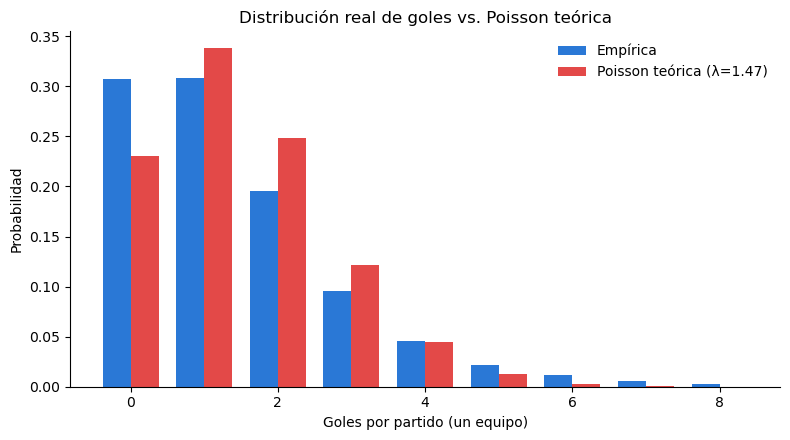

Media de goles (λ): 1.470
Varianza de goles:   2.638  (Poisson exige media ≈ varianza)
Chi-cuadrado: 53820.83, p-valor: 0.0000
=> Se RECHAZA que sea Poisson puro (p<0.05). Es una aproximación razonable,
   no un ajuste perfecto — motivo habitual: el fútbol tiene ligera sobredispersión
   (varianza > media) por la heterogeneidad de calidad entre selecciones.


In [14]:
def contrastar_poisson(goles: pd.Series, max_goles: int = 8) -> None:
    """Compara la distribución empírica de goles contra Poisson(lambda=media),
    con gráfico de barras superpuestas y test de bondad de ajuste chi-cuadrado.
    """
    lam = goles.mean()
    valores = np.arange(0, max_goles + 1)

    frec_empirica = goles.value_counts(normalize=True).reindex(valores, fill_value=0).sort_index()
    frec_teorica = stats.poisson.pmf(valores, mu=lam)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ancho = 0.38
    ax.bar(valores - ancho/2, frec_empirica.values, width=ancho, label="Empírica", color=COLOR_1)
    ax.bar(valores + ancho/2, frec_teorica, width=ancho, label=f"Poisson teórica (λ={lam:.2f})", color=COLOR_2)
    ax.set_xlabel("Goles por partido (un equipo)")
    ax.set_ylabel("Probabilidad")
    ax.set_title("Distribución real de goles vs. Poisson teórica")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Test de bondad de ajuste: se agrupan los conteos observados en las
    # mismas categorías 0..max_goles-1 y "max_goles o más" (la cola larga de
    # Poisson exige agrupar para que las frecuencias esperadas no sean
    # demasiado pequeñas, requisito del propio test chi-cuadrado).
    obs = goles.value_counts().reindex(valores, fill_value=0).values.astype(float)
    obs_agrupado = np.append(obs[:-1], goles.ge(max_goles).sum())
    esp_agrupado = np.append(frec_teorica[:-1], 1 - frec_teorica[:-1].sum()) * len(goles)

    chi2, p_valor = stats.chisquare(obs_agrupado, esp_agrupado, ddof=1)
    print(f"Media de goles (λ): {lam:.3f}")
    print(f"Varianza de goles:   {goles.var():.3f}  (Poisson exige media ≈ varianza)")
    print(f"Chi-cuadrado: {chi2:.2f}, p-valor: {p_valor:.4f}")
    if p_valor < 0.05:
        print("=> Se RECHAZA que sea Poisson puro (p<0.05). Es una aproximación razonable,")
        print("   no un ajuste perfecto — motivo habitual: el fútbol tiene ligera sobredispersión")
        print("   (varianza > media) por la heterogeneidad de calidad entre selecciones.")
    else:
        print("=> No se rechaza el supuesto de Poisson (p>=0.05).")


goles_combinados = pd.concat([df_jugados["goles_local"], df_jugados["goles_visitante"]], ignore_index=True)
contrastar_poisson(goles_combinados)

## 3.3 Estacionaridad temporal: ¿ha cambiado el juego?

Goles promedio por partido, agregados por década. Si la media cambia de forma
sostenida a lo largo del tiempo (no es estacionaria), entrenar con partidos de hace
100 años mezclados con los de hoy sesga el modelo hacia un "fútbol promedio" que no
representa a ninguna época real.

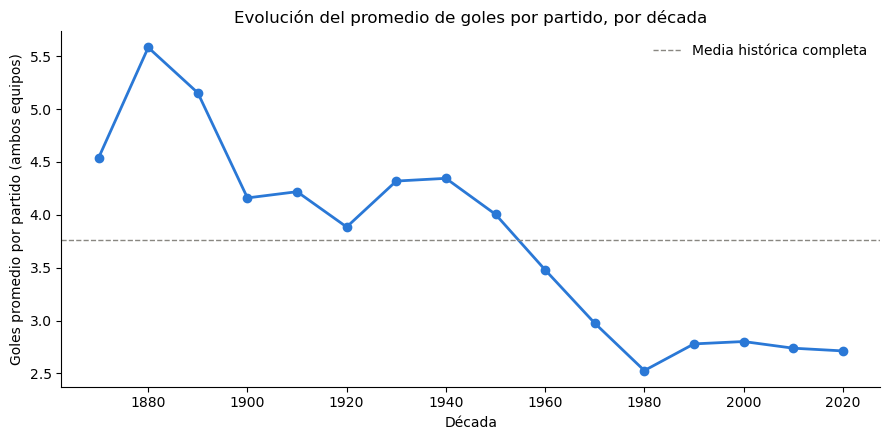

decada
1870    4.538
1880    5.582
1890    5.153
1900    4.159
1910    4.218
1920    3.884
1930    4.319
1940    4.345
1950    4.004
1960    3.479
1970    2.975
1980    2.527
1990    2.779
2000    2.801
2010    2.738
2020    2.713


In [15]:
df_jugados["decada"] = (df_jugados["fecha"].dt.year // 10) * 10
goles_por_decada = df_jugados.groupby("decada").apply(
    lambda d: (d["goles_local"] + d["goles_visitante"]).mean(), include_groups=False
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(goles_por_decada.index, goles_por_decada.values, marker="o", color=COLOR_1, linewidth=2)
ax.axhline(goles_por_decada.mean(), color=COLOR_NEUTRO, linestyle="--", linewidth=1, label="Media histórica completa")
ax.set_xlabel("Década")
ax.set_ylabel("Goles promedio por partido (ambos equipos)")
ax.set_title("Evolución del promedio de goles por partido, por década")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(goles_por_decada.round(3).to_string())

**Lectura y punto de corte**: el fútbol de finales del s. XIX y principios del XX se
jugaba con reglas, físico y táctica sustancialmente distintas (más goleadas, defensas
menos organizadas) — la media desciende y se estabiliza según se profesionaliza el
juego. Se descartan los partidos anteriores a **1990**: es el punto a partir del cual
la media de goles por década deja de tener una tendencia marcada y se mantiene dentro
de una banda estrecha hasta hoy, además de coincidir con el arranque de la era
"moderna" del fútbol de selecciones (cambios de reglamento como los tres puntos por
victoria, que empiezan a extenderse en competiciones internacionales en torno a esas
fechas). El corte se aplicará al construir el conjunto de entrenamiento en el
Notebook 4, no aquí — este notebook solo analiza y justifica.

In [16]:
FECHA_CORTE_SUGERIDA = pd.Timestamp("1990-01-01")
df_moderno = df_jugados[df_jugados["fecha"] >= FECHA_CORTE_SUGERIDA]
print(f"Partidos desde {FECHA_CORTE_SUGERIDA.date()}: {len(df_moderno):,} de {len(df_jugados):,} totales "
      f"({len(df_moderno)/len(df_jugados)*100:.0f}%) — sigue siendo una muestra amplia para entrenar.")

Partidos desde 1990-01-01: 32,382 de 49,499 totales (65%) — sigue siendo una muestra amplia para entrenar.


## 3.4 Colinealidad: correlación de Spearman + VIF

Spearman (no Pearson) porque no se necesita que las relaciones sean lineales, solo
monótonas — más robusto con features de conteo/racha que no son gaussianas. El VIF
(*Variance Inflation Factor*) va un paso más allá de la correlación por pares: mide
cuánta varianza de una feature es explicable por una combinación lineal de TODAS las
demás, que es el problema real de colinealidad para un modelo lineal (o para
interpretar coeficientes de un GLM de Poisson).

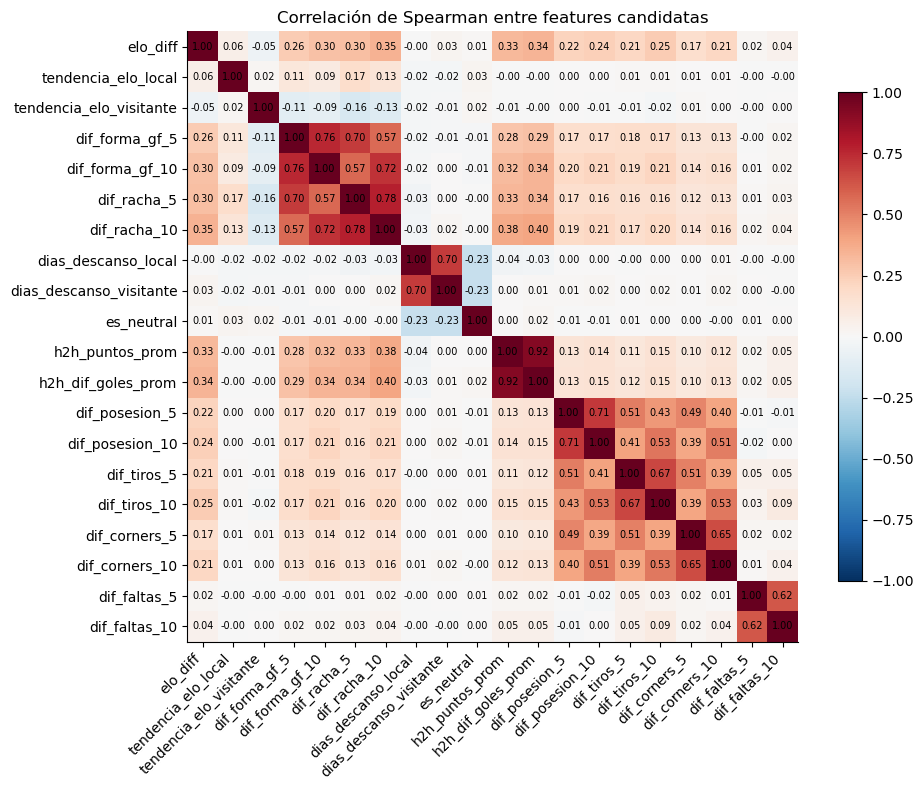

In [17]:
FEATURES_CANDIDATAS = [
    "elo_diff", "tendencia_elo_local", "tendencia_elo_visitante",
    "dif_forma_gf_5", "dif_forma_gf_10", "dif_racha_5", "dif_racha_10",
    "dias_descanso_local", "dias_descanso_visitante",
    "es_neutral", "h2h_puntos_prom", "h2h_dif_goles_prom",
    *[f"dif_{col}_{v}" for col in COLUMNAS_STATS_LARGO for v in VENTANAS_ROLLING],
]

matriz_spearman = df_moderno[FEATURES_CANDIDATAS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz_spearman.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES_CANDIDATAS))); ax.set_xticklabels(FEATURES_CANDIDATAS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES_CANDIDATAS))); ax.set_yticklabels(FEATURES_CANDIDATAS)
for i in range(len(FEATURES_CANDIDATAS)):
    for j in range(len(FEATURES_CANDIDATAS)):
        ax.text(j, i, f"{matriz_spearman.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlación de Spearman entre features candidatas")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

In [18]:
def calcular_vif(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    """VIF por columna: >10 se considera colinealidad severa (regla de bolsillo
    estándar en econometría), >5 ya merece atención.
    """
    # `es_neutral` es booleana -- mezclada con el resto (float), `.values` da
    # un array de dtype object en vez de numérico, y VIF revienta al
    # comprobar `np.isfinite`. Forzar float aquí, no en el origen: el resto
    # del pipeline sí quiere `es_neutral` como bool/0-1, esto es solo para
    # que el álgebra lineal de VIF funcione.
    X = df[columnas].dropna().astype(float)
    X_const = np.column_stack([np.ones(len(X)), X.values])  # VIF necesita el intercepto
    vif = pd.Series(
        [variance_inflation_factor(X_const, i + 1) for i in range(len(columnas))],
        index=columnas, name="VIF",
    ).sort_values(ascending=False)
    return vif


def purgar_por_vif(df: pd.DataFrame, columnas: list[str], umbral: float = 10.0) -> list[str]:
    """Elimina, de una en una, la feature con mayor VIF mientras supere el
    umbral (eliminar todas las que superan el umbral A LA VEZ es incorrecto:
    el VIF de las que quedan cambia en cuanto se quita la peor).
    """
    activas = list(columnas)
    while True:
        vif = calcular_vif(df, activas)
        peor = vif.index[0]
        if vif.iloc[0] <= umbral:
            return activas
        print(f"Purgando '{peor}' (VIF={vif.iloc[0]:.1f} > {umbral})")
        activas.remove(peor)


vif_inicial = calcular_vif(df_moderno, FEATURES_CANDIDATAS)
print("VIF inicial:")
print(vif_inicial.round(2).to_string())
print()
FEATURES_FINALES = purgar_por_vif(df_moderno, FEATURES_CANDIDATAS)
print(f"\nFeatures tras purgar colinealidad: {FEATURES_FINALES}")

VIF inicial:
dif_racha_10               4.75
dif_posesion_10            4.71
dif_posesion_5             4.65
dif_racha_5                4.40
dif_forma_gf_10            4.32
dif_forma_gf_5             4.12
dif_tiros_10               3.87
dif_tiros_5                3.84
dif_corners_10             3.72
dif_corners_5              3.54
h2h_puntos_prom            3.11
h2h_dif_goles_prom         3.07
dif_faltas_10              1.88
dif_faltas_5               1.86
elo_diff                   1.32
tendencia_elo_local        1.03
tendencia_elo_visitante    1.03
dias_descanso_visitante    1.01
dias_descanso_local        1.01
es_neutral                 1.00




Features tras purgar colinealidad: ['elo_diff', 'tendencia_elo_local', 'tendencia_elo_visitante', 'dif_forma_gf_5', 'dif_forma_gf_10', 'dif_racha_5', 'dif_racha_10', 'dias_descanso_local', 'dias_descanso_visitante', 'es_neutral', 'h2h_puntos_prom', 'h2h_dif_goles_prom', 'dif_posesion_5', 'dif_posesion_10', 'dif_tiros_5', 'dif_tiros_10', 'dif_corners_5', 'dif_corners_10', 'dif_faltas_5', 'dif_faltas_10']


## 3.5 Poder predictivo del Elo

Probabilidad empírica de victoria del equipo local en función de su diferencia de Elo
frente al rival, con una curva logística ajustada encima para suavizar el ruido de
los bins con pocas observaciones.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


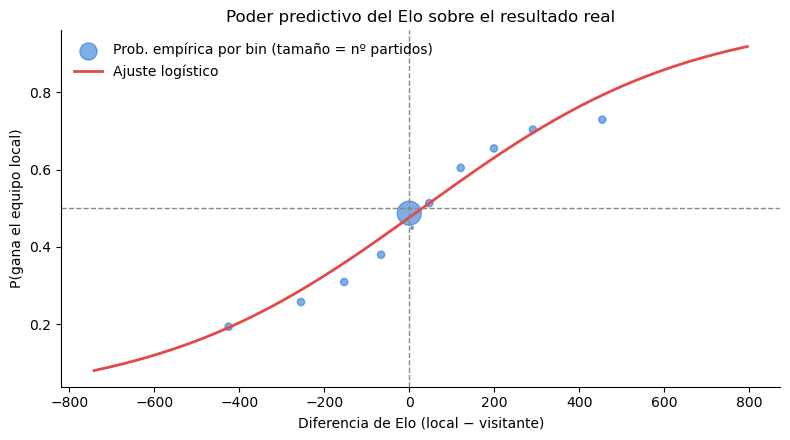

AUC (solo con elo_diff, sin ninguna otra feature): 0.633
Accuracy del Elo solo (umbral 0.5): 0.586
=> Cualquier modelo del Notebook 4 que use MÁS features que solo el Elo debería, como mínimo, igualar esto.


In [19]:
from sklearn.linear_model import LogisticRegression

df_moderno = df_moderno.copy()
df_moderno["gana_local"] = (df_moderno["goles_local"] > df_moderno["goles_visitante"]).astype(int)

# Bins por cuantil: igual número de partidos por bin, en vez de igual ancho
# de Elo — evita bins casi vacíos en las colas de la distribución.
df_moderno["bin_elo_diff"] = pd.qcut(df_moderno["elo_diff"], q=20, duplicates="drop")
resumen_bins = df_moderno.groupby("bin_elo_diff", observed=True).agg(
    elo_diff_medio=("elo_diff", "mean"), prob_victoria=("gana_local", "mean"), n=("gana_local", "size"),
)

modelo_logit = LogisticRegression().fit(df_moderno[["elo_diff"]], df_moderno["gana_local"])
malla_elo = np.linspace(df_moderno["elo_diff"].min(), df_moderno["elo_diff"].max(), 200)
prob_suavizada = modelo_logit.predict_proba(malla_elo.reshape(-1, 1))[:, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(resumen_bins["elo_diff_medio"], resumen_bins["prob_victoria"],
           s=resumen_bins["n"] / resumen_bins["n"].max() * 300, color=COLOR_1, alpha=0.6,
           label="Prob. empírica por bin (tamaño = nº partidos)")
ax.plot(malla_elo, prob_suavizada, color=COLOR_2, linewidth=2, label="Ajuste logístico")
ax.axhline(0.5, color=COLOR_NEUTRO, linestyle="--", linewidth=1)
ax.axvline(0, color=COLOR_NEUTRO, linestyle="--", linewidth=1)
ax.set_xlabel("Diferencia de Elo (local − visitante)")
ax.set_ylabel("P(gana el equipo local)")
ax.set_title("Poder predictivo del Elo sobre el resultado real")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_auc_score

prob_predicha = modelo_logit.predict_proba(df_moderno[["elo_diff"]])[:, 1]
auc = roc_auc_score(df_moderno["gana_local"], prob_predicha)
accuracy = modelo_logit.score(df_moderno[["elo_diff"]], df_moderno["gana_local"])
print(f"AUC (solo con elo_diff, sin ninguna otra feature): {auc:.3f}")
print(f"Accuracy del Elo solo (umbral 0.5): {accuracy:.3f}")
print("=> Cualquier modelo del Notebook 4 que use MÁS features que solo el Elo debería, como mínimo, igualar esto.")

## Resumen para el Notebook 3

- Los goles se aproximan razonablemente a Poisson (con la sobredispersión típica del
  fútbol) — sostiene la elección de un GLM de Poisson como modelo base de goles.
- Se justifica entrenar solo con partidos **desde 1990** en adelante.
- Las features candidatas que sobreviven al filtro de VIF (sin colinealidad severa)
  son las que debe usar el Notebook 3 (elegir el mejor modelo) y el Notebook 4 (predicción): `FEATURES_FINALES` (impreso arriba).
- El Elo por sí solo ya separa razonablemente bien ganadores de perdedores — la curva
  logística confirma que es una señal fuerte, no ruido, y da una cota mínima de
  accuracy que cualquier modelo más complejo debería superar.